In [1]:
import os
import glob
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

# Enforce reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Compute Device: {device}")

Compute Device: cuda


## 1. Evaluation Framework & Data Split Strategy

**Objective:** To accurately evaluate how well the drone gesture classifier will perform in a real-world deployment (e.g., the upcoming client demo).

**Methodology & Justification:** A standard randomized 80/20 train-validation split would result in *data leakage*. Because the dataset consists of specific subjects (e.g., S1, S3, S11) performing multiple iterations of gestures, randomly splitting instances would mean frames of the same subject appear in both the training and validation sets. In this scenario, the network might memorize subject-specific features (e.g., clothing color, room lighting, body proportions) rather than learning the generalized spatial geometry of the hand gestures. 

To ensure the model generalizes to *unseen humans*—a mandatory requirement for demo day—we implement a **Subject-Wise Split**. We isolate a subset of subjects completely from the training phase and reserve them exclusively for validation. This rigorous evaluation framework guarantees that our validation metrics reflect actual deployment readiness.

In [2]:
class DroneGestureDataset(Dataset):
    def __init__(self, root_dir, is_train=True, val_subjects=None, transform=None):
        """
        Args:
            root_dir (str): Path to the 'data_resized' directory.
            is_train (bool): If True, loads training subjects. If False, loads validation subjects.
            val_subjects (list): List of subject folder names to be used for validation (e.g., ['S13', 'S14', 'S15']).
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.root_dir = root_dir
        self.transform = transform
        self.is_train = is_train
        
        if val_subjects is None:
            # Defaulting to 3 subjects for validation to test generalization
            val_subjects = ['S13', 'S14', 'S15'] 
            
        self.instances = [] 
        self.classes = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])
        self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}

        # Traverse the hierarchical directory structure
        for cls_name in self.classes:
            cls_path = os.path.join(root_dir, cls_name)
            
            for subject_id in os.listdir(cls_path):
                subj_path = os.path.join(cls_path, subject_id)
                if not os.path.isdir(subj_path): continue

                # Subject-wise split logic
                is_val_subject = subject_id in val_subjects
                if (self.is_train and is_val_subject) or (not self.is_train and not is_val_subject):
                    continue 

                for instance_id in os.listdir(subj_path):
                    inst_path = os.path.join(subj_path, instance_id)
                    if not os.path.isdir(inst_path): continue

                    # Grab all PNG frames and sort them to maintain temporal order (1 to 5)
                    frames = sorted(glob.glob(os.path.join(inst_path, '*.png')))
                    if len(frames) == 5:
                        self.instances.append((frames, self.class_to_idx[cls_name]))

    def __len__(self):
        return len(self.instances)

    def __getitem__(self, idx):
        frame_paths, label = self.instances[idx]
        frames = []

        # Load and transform each frame in the instance sequence
        for path in frame_paths:
            img = Image.open(path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            frames.append(img)

        # Stack the 5 frames. Resulting shape: [5, Channels, Height, Width]
        frames_tensor = torch.stack(frames)
        
        return frames_tensor, label

print("Dataset class successfully defined.")

Dataset class successfully defined.


In [3]:
# Cell 4: Data Transformations & Loaders

# Define the spatial dimensions required by standard pre-trained CNNs
img_height, img_width = 224, 224

# Training transforms include data augmentation to help the model generalize
train_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    # Standard ImageNet normalization values
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Validation transforms only resize and normalize, no augmentation
val_transforms = transforms.Compose([
    transforms.Resize((img_height, img_width)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                         std=[0.229, 0.224, 0.225])
])

# Initialize the datasets using the custom class
root_data_path = './data_resized'

train_dataset = DroneGestureDataset(
    root_dir=root_data_path, 
    is_train=True, 
    transform=train_transforms
)

val_dataset = DroneGestureDataset(
    root_dir=root_data_path, 
    is_train=False, 
    transform=val_transforms
)

# Set up DataLoaders to batch and shuffle the data for training
batch_size = 16

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Training instances: {len(train_dataset)}")
print(f"Validation instances: {len(val_dataset)}")

Training instances: 817
Validation instances: 242


## 2. Network Architecture: Late Fusion 2D CNN

**Objective:** To process a sequence of 5 frames per instance using only a 2-D Convolutional Neural Network, ensuring the model remains lightweight enough for an embedded drone system while still utilizing all available temporal information.

**Methodology & Justification:** Instead of modifying a 2D CNN to accept a 15-channel stacked input (Early Fusion)—which would destroy the pre-trained first-layer weights and risk overfitting on our small dataset—we implement a **Late Fusion (Feature Aggregation)** architecture. 

We utilize a pre-trained `ResNet18` as the feature extraction backbone. `ResNet18` is chosen because it offers an excellent balance between representational capacity and computational efficiency, making it highly suitable for hardware-constrained environments. 

During the forward pass, the 5 frames of an instance are passed through the 2D CNN independently. The network extracts 5 distinct feature vectors. We then apply Mean Pooling across the temporal dimension to aggregate these 5 vectors into a single robust representation of the gesture. Finally, this aggregated vector is passed to a fully connected linear layer for the 13-class prediction. This approach preserves 100% of the ImageNet pre-trained weights, efficiently utilizes all 5 frames, and strictly adheres to the hardware and architectural constraints.

In [4]:
# Cell 6: Late Fusion Network Architecture

class LateFusionGestureModel(nn.Module):
    def __init__(self, num_classes=13):
        super(LateFusionGestureModel, self).__init__()
        
        # Load a pre-trained ResNet18 backbone for feature extraction
        # Weights are downloaded automatically from torchvision
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        
        # Extract the number of input features going into the original classifier
        in_features = self.backbone.fc.in_features
        
        # Remove the final fully connected layer so the backbone only outputs feature vectors
        self.backbone.fc = nn.Identity()
        
        # Define our custom classification head for the 13 gesture classes
        self.classifier = nn.Linear(in_features, num_classes)
        
    def forward(self, x):
        # x input shape: [batch_size, num_frames, channels, height, width]
        batch_size, num_frames, c, h, w = x.size()
        
        # Merge the batch and frame dimensions so the 2D CNN can process all images
        # New shape: [batch_size * 5, 3, 224, 224]
        x = x.view(batch_size * num_frames, c, h, w)
        
        # Pass the images through the backbone to get feature vectors
        # Output shape: [batch_size * 5, 512]
        features = self.backbone(x)
        
        # Separate the batch and frame dimensions again
        # New shape: [batch_size, 5, 512]
        features = features.view(batch_size, num_frames, -1)
        
        # Aggregate the features across the 5 frames using Mean Pooling
        # This condenses the sequence into a single representative vector per instance
        # Output shape: [batch_size, 512]
        aggregated_features = torch.mean(features, dim=1)
        
        # Pass the final aggregated vector through the classification head
        # Output shape: [batch_size, 13]
        out = self.classifier(aggregated_features)
        
        return out

# Instantiate the model and move it to the configured device (CPU or GPU)
model = LateFusionGestureModel(num_classes=13).to(device)
print("Late Fusion Model successfully initialized.")

Late Fusion Model successfully initialized.


In [5]:
# Cell 7: Loss Function & Optimizer

# CrossEntropyLoss automatically applies Softmax, so our model outputs raw logits
criterion = nn.CrossEntropyLoss()

# Adam optimizer is highly efficient for CNNs. 
# A learning rate of 1e-4 is a safe, stable starting point for pre-trained backbones.
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Number of complete passes through the dataset
# We keep this relatively small (e.g., 10-15) for the baseline to ensure it runs quickly on AWS
num_epochs = 10

# Dictionary to store metrics for visualization later
history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': []
}

print("Optimizer and Loss Function configured.")

Optimizer and Loss Function configured.


In [6]:
# Cell 8: Training Loop

print("Starting Training Phase...")

for epoch in range(num_epochs):
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode (enables dropout, batch norm updates)
    running_loss = 0.0
    correct_train = 0
    total_train = 0
    
    for inputs, labels in train_loader:
        # Move data to the same device as the model (CPU or GPU)
        inputs, labels = inputs.to(device), labels.to(device)
        
        # 1. Zero the gradients so they don't accumulate from the previous batch
        optimizer.zero_grad()
        
        # 2. Forward pass: compute predictions
        outputs = model(inputs)
        
        # 3. Compute the loss
        loss = criterion(outputs, labels)
        
        # 4. Backward pass: compute gradients
        loss.backward()
        
        # 5. Update weights
        optimizer.step()
        
        # Track metrics
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # --- VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode (disables dropout, freezes batch norm)
    val_loss = 0.0
    correct_val = 0
    total_val = 0
    
    # Disable gradient calculation to save memory and compute during validation
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    # Save metrics to history for visualization
    history['train_loss'].append(epoch_train_loss)
    history['val_loss'].append(epoch_val_loss)
    history['train_acc'].append(epoch_train_acc)
    history['val_acc'].append(epoch_val_acc)
    
    # Print detailed output for the epoch
    print(f"Epoch [{epoch+1}/{num_epochs}] "
          f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | "
          f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.2f}%")
          
print("Training Complete!")

Starting Training Phase...
Epoch [1/10] Train Loss: 1.6485, Train Acc: 46.76% | Val Loss: 1.3625, Val Acc: 47.11%
Epoch [2/10] Train Loss: 0.6637, Train Acc: 84.33% | Val Loss: 1.6377, Val Acc: 40.91%
Epoch [3/10] Train Loss: 0.3313, Train Acc: 91.92% | Val Loss: 1.3434, Val Acc: 51.24%
Epoch [4/10] Train Loss: 0.2136, Train Acc: 94.98% | Val Loss: 1.3055, Val Acc: 57.02%
Epoch [5/10] Train Loss: 0.1238, Train Acc: 97.31% | Val Loss: 1.3212, Val Acc: 56.61%
Epoch [6/10] Train Loss: 0.0774, Train Acc: 99.27% | Val Loss: 1.2235, Val Acc: 50.83%
Epoch [7/10] Train Loss: 0.0639, Train Acc: 99.27% | Val Loss: 1.3131, Val Acc: 51.65%
Epoch [8/10] Train Loss: 0.0719, Train Acc: 98.41% | Val Loss: 1.5716, Val Acc: 52.89%
Epoch [9/10] Train Loss: 0.0453, Train Acc: 99.76% | Val Loss: 1.3082, Val Acc: 52.48%
Epoch [10/10] Train Loss: 0.0469, Train Acc: 99.27% | Val Loss: 1.3064, Val Acc: 54.13%
Training Complete!


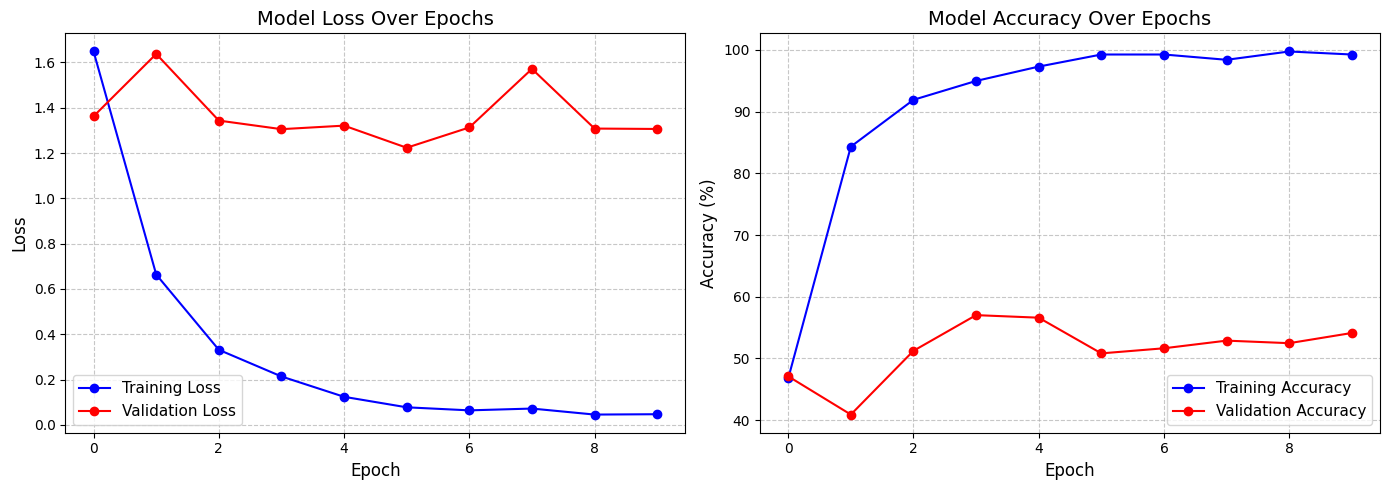

In [7]:
# Cell 9: Learning Curve Visualization

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Loss Curve
axes[0].plot(history['train_loss'], label='Training Loss', color='blue', marker='o')
axes[0].plot(history['val_loss'], label='Validation Loss', color='red', marker='o')
axes[0].set_title('Model Loss Over Epochs', fontsize=14)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: Accuracy Curve
axes[1].plot(history['train_acc'], label='Training Accuracy', color='blue', marker='o')
axes[1].plot(history['val_acc'], label='Validation Accuracy', color='red', marker='o')
axes[1].set_title('Model Accuracy Over Epochs', fontsize=14)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()